# SSP-SLAM Walkthrough

This notebook walks through the full Semantic Spiking Neural SLAM pipeline step by step —
no GPU or special hardware required.

**What you'll see:**
1. Spatial Semantic Pointers (SSPs) — encoding & decoding positions
2. Semantic Pointers (SPs) — discrete symbol algebra
3. Image feature encoding → unitary SPs
4. Semantic landmark encoding — binding appearance + class
5. Loading pre-collected 3D data and visualising the map
6. Querying SLAM results — where did the network learn each object is?

---

In [87]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os

# Make sure the library is on the path when running from experiments/
sys.path.insert(1, os.path.dirname(os.path.dirname(os.path.abspath('.'))))

import sspslam
from sspslam import HexagonalSSPSpace, SPSpace

print(f"sspslam version: {sspslam.__version__ if hasattr(sspslam, '__version__') else 'ok'}")

sspslam version: ok


## 1. Spatial Semantic Pointers (SSPs)

An SSP encodes a continuous 2D position as a fixed-length vector using
Hexagonal grid-cell-inspired Fourier features. The key properties are:
- Similar positions → similar vectors (smooth)
- Vectors are unitary (norm ≈ 1)
- Can be decoded back to (x, y) via similarity search

In [88]:
ssp_space = HexagonalSSPSpace(
    domain_dim=2,
    n_scales=8,
    n_rotates=5,
    length_scale=0.3,
    domain_bounds=np.array([[-1, 1], [-1, 1]]),
)

print(f"SSP dimension: {ssp_space.ssp_dim}")
print(f"Domain dim:    {ssp_space.domain_dim}")

# Encode positions — squeeze() converts (1, ssp_dim) → (ssp_dim,) for single points
pos_A = np.array([0.3, -0.5])
pos_B = np.array([0.31, -0.5])   # very close to A
pos_C = np.array([-0.8,  0.7])   # far from A

ssp_A = ssp_space.encode(pos_A).squeeze()
ssp_B = ssp_space.encode(pos_B).squeeze()
ssp_C = ssp_space.encode(pos_C).squeeze()

print(f"\nSSP shape: {ssp_A.shape}")
print(f"Similarity A-B (nearby):  {np.dot(ssp_A, ssp_B):.4f}   ← high")
print(f"Similarity A-C (far):     {np.dot(ssp_A, ssp_C):.4f}   ← low")

SSP dimension: 241
Domain dim:    2

SSP shape: (241,)
Similarity A-B (nearby):  0.9987   ← high
Similarity A-C (far):     0.0051   ← low


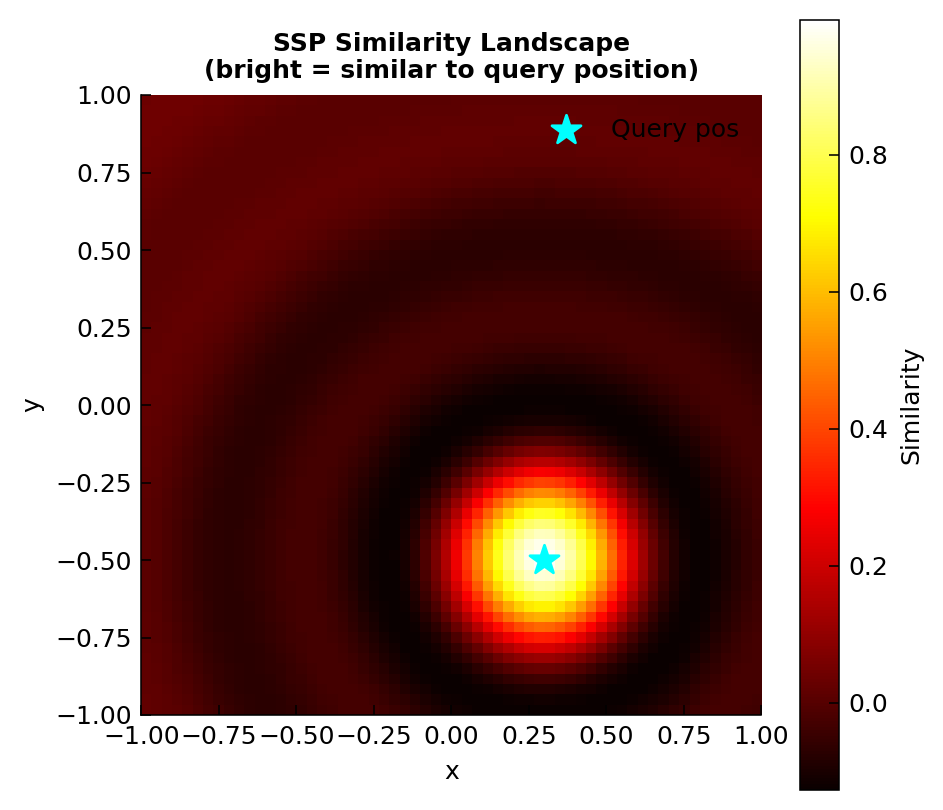

In [89]:
# Visualise the similarity landscape around pos_A
resolution = 60
xs = np.linspace(-1, 1, resolution)
ys = np.linspace(-1, 1, resolution)
xx, yy = np.meshgrid(xs, ys)
grid_pts = np.stack([xx.ravel(), yy.ravel()], axis=1)
grid_ssps = ssp_space.encode(grid_pts)            # (resolution^2, ssp_dim)

sims = (grid_ssps @ ssp_A).reshape(resolution, resolution)

plt.figure(figsize=(5, 5))
plt.imshow(sims, origin='lower', extent=[-1, 1, -1, 1], cmap='hot')
plt.colorbar(label='Similarity')
plt.scatter(*pos_A, s=120, color='cyan', marker='*', zorder=5, label='Query pos')
plt.title('SSP Similarity Landscape\n(bright = similar to query position)')
plt.legend()
plt.xlabel('x'); plt.ylabel('y')
plt.show()

In [90]:
# Decode: SSP → (x, y)
# decode() expects a 2D input (n, ssp_dim), so we reshape before passing
decoded = ssp_space.decode(ssp_A.reshape(1, -1), method='from-set', items='grid', n_items=100)
decoded = np.array(decoded).squeeze()
print(f"True position:    {pos_A}")
print(f"Decoded position: {np.round(decoded, 3)}")
print(f"Error:            {np.linalg.norm(pos_A - decoded):.4f} units")

True position:    [ 0.3 -0.5]
Decoded position: [ 0.298 -0.498]
Error:            0.0029 units


## 2. Semantic Pointers (SPs) — Symbol Algebra

SPs encode discrete symbols (e.g. landmark identities) as unitary vectors.
They support binding (`⊛`) and unbinding (`⊛⁻¹`) — the key operations for
associating identities with locations.

In [91]:
sp_space = SPSpace(domain_size=6, dim=151, seed=0)

# Symbols: shape and colour SPs — each is a 1D unitary vector
TRIANGLE, SQUARE = sp_space.vectors[0], sp_space.vectors[1]
BLUE, ORANGE     = sp_space.vectors[2], sp_space.vectors[3]

# bind() and invert() always return (n_samples, dim) — squeeze to 1D
blue_triangle = sp_space.bind(TRIANGLE, BLUE).squeeze()
orange_square = sp_space.bind(SQUARE,   ORANGE).squeeze()

print("SP dimension:", sp_space.dim)
print("\nBinding sanity checks (unbind = bind with inverse):")
unbound = sp_space.bind(sp_space.invert(BLUE), blue_triangle).squeeze()
print(f"  unbind(blue_triangle, BLUE) · TRIANGLE = {np.dot(unbound, TRIANGLE):.3f}   ← high")
print(f"  unbind(blue_triangle, BLUE) · SQUARE   = {np.dot(unbound, SQUARE):.3f}   ← low")

# Superposition: store multiple items, then retrieve one
memory = blue_triangle + orange_square
result = sp_space.bind(sp_space.invert(BLUE), memory).squeeze()
print(f"\nSuperposition query for BLUE:")
print(f"  similarity to TRIANGLE: {np.dot(result, TRIANGLE):.3f}   ← should be highest")
print(f"  similarity to SQUARE:   {np.dot(result, SQUARE):.3f}")
print(f"  similarity to ORANGE:   {np.dot(result, ORANGE):.3f}")

SP dimension: 151

Binding sanity checks (unbind = bind with inverse):
  unbind(blue_triangle, BLUE) · TRIANGLE = 0.997   ← high
  unbind(blue_triangle, BLUE) · SQUARE   = -0.002   ← low

Superposition query for BLUE:
  similarity to TRIANGLE: 1.001   ← should be highest
  similarity to SQUARE:   0.000
  similarity to ORANGE:   -0.009


## 3. Image Feature Encoding → Unitary SPs

`ImageFeatureEncoder` uses a random projection (Johnson-Lindenstrauss) to map
any continuous feature vector (SIFT, HOG, ORB, CLIP) into the SP space as a
unitary vector — preserving cosine similarity.

In [92]:
from sspslam.perception import ImageFeatureEncoder

FEAT_DIM = 128   # e.g. SIFT descriptor
SSP_DIM  = 151

encoder = ImageFeatureEncoder(feat_dim=FEAT_DIM, ssp_dim=SSP_DIM, seed=0)

# Simulate two similar and one dissimilar feature vector
rng = np.random.default_rng(42)
base_feat  = rng.standard_normal(FEAT_DIM)
close_feat = base_feat + 0.05 * rng.standard_normal(FEAT_DIM)
diff_feat  = rng.standard_normal(FEAT_DIM)

# encode() returns (1, ssp_dim) for a single vector — squeeze to (ssp_dim,)
sp_base  = encoder.encode(base_feat).squeeze()
sp_close = encoder.encode(close_feat).squeeze()
sp_diff  = encoder.encode(diff_feat).squeeze()

print(f"Output SP norm: {np.linalg.norm(sp_base):.4f}  (should be ≈ 1)")
print(f"\nSimilarity preservation:")
print(f"  Feature cos-sim (base, close): {np.dot(base_feat, close_feat) / (np.linalg.norm(base_feat)*np.linalg.norm(close_feat)):.3f}")
print(f"  SP      cos-sim (base, close): {np.dot(sp_base, sp_close):.3f}   ← should be similar")
print(f"  Feature cos-sim (base, diff):  {np.dot(base_feat, diff_feat)  / (np.linalg.norm(base_feat)*np.linalg.norm(diff_feat)):.3f}")
print(f"  SP      cos-sim (base, diff):  {np.dot(sp_base, sp_diff):.3f}   ← should be lower")

Output SP norm: 1.0000  (should be ≈ 1)

Similarity preservation:
  Feature cos-sim (base, close): 0.998
  SP      cos-sim (base, close): 0.996   ← should be similar
  Feature cos-sim (base, diff):  0.028
  SP      cos-sim (base, diff):  0.017   ← should be lower


In [93]:
try:
    from sspslam.perception import extract_hog
    img = (np.random.rand(64, 64, 3) * 255).astype(np.uint8)
    hog_feat = extract_hog(img)
    enc_hog = ImageFeatureEncoder(feat_dim=hog_feat.shape[0], ssp_dim=SSP_DIM, seed=1)
    sp_hog = enc_hog.encode(hog_feat).squeeze()
    print(f"HOG descriptor dim: {hog_feat.shape[0]}")
    print(f"HOG → SP norm: {np.linalg.norm(sp_hog):.4f}")
except ImportError as e:
    print(f"scikit-image not available ({e}) — skipping HOG demo")

HOG descriptor dim: 1764
HOG → SP norm: 1.0000


## 4. Semantic Landmark Encoding

`SemanticLandmarkEncoder` binds visual appearance with semantic class labels.
This allows class-level queries: *"show me all chairs"* or *"where is the blue thing?"*

In [94]:
from sspslam import SemanticLandmarkEncoder

LABEL_NAMES = ["red_box", "blue_box", "green_ball", "yellow_ball"]
feat_dim    = 64
ssp_dim     = 151

sem_enc = SemanticLandmarkEncoder(
    image_encoder=ImageFeatureEncoder(feat_dim=feat_dim, ssp_dim=ssp_dim, seed=0),
    sp_space=SPSpace(domain_size=len(LABEL_NAMES), dim=ssp_dim, seed=0),
    label_names=LABEL_NAMES,
)

rng = np.random.default_rng(99)
landmark_features = [rng.standard_normal(feat_dim) for _ in LABEL_NAMES]

# get_semantic_sp expects a dict {label_name: probability}
def one_hot_dict(i, names):
    return {name: (1.0 if j == i else 0.0) for j, name in enumerate(names)}

landmark_sps = [
    sem_enc.encode(landmark_features[i], one_hot_dict(i, LABEL_NAMES))
    for i in range(len(LABEL_NAMES))
]

print("Landmark SP norms:", [f"{np.linalg.norm(sp):.3f}" for sp in landmark_sps])

Landmark SP norms: ['1.000', '0.998', '0.998', '0.981']


In [95]:
# Class query: "find all red_box landmarks"
app_sps = np.array([sem_enc.get_appearance_sp(f) for f in landmark_features])
query = sem_enc.class_query_sp("red_box", app_sps)

print("Class query 'red_box' similarity to each landmark:")
for i, (name, sp) in enumerate(zip(LABEL_NAMES, landmark_sps)):
    sim = float(np.dot(query.squeeze(), np.array(sp).squeeze()))
    bar = '█' * int(max(0, sim) * 30)
    print(f"  {name:15s}: {sim:+.3f}  {bar}")

Class query 'red_box' similarity to each landmark:
  red_box        : +0.460  █████████████
  blue_box       : -0.079  
  green_ball     : -0.046  
  yellow_ball    : -0.049  


## 5. Load Pre-Collected 3D Data

The `data/3d/` directory contains a trajectory and feature vectors from a
MiniWorld SLAMRoom collected using `collect_3d_data.py`.

In [96]:
DATA_DIR = os.path.join(os.path.dirname(os.path.abspath('.')), 'data', '3d')
if not os.path.exists(DATA_DIR):
    DATA_DIR = '../data/3d'

path               = np.load(os.path.join(DATA_DIR, 'path.npy'))
velocities         = np.load(os.path.join(DATA_DIR, 'velocities.npy'))
vec_to_landmarks   = np.load(os.path.join(DATA_DIR, 'vec_to_landmarks.npy'))
landmark_positions = np.load(os.path.join(DATA_DIR, 'landmark_positions.npy'))
feature_vectors    = np.load(os.path.join(DATA_DIR, 'feature_vectors.npy')).astype(np.float32)

import json
with open(os.path.join(DATA_DIR, 'metadata.json')) as f:
    meta = json.load(f)

T, n_obj, feat_dim = feature_vectors.shape
labels = meta.get('landmark_labels', [f'obj_{i}' for i in range(n_obj)])

print(f"Timesteps:   {T}")
print(f"Objects:     {n_obj}  {labels}")
print(f"Feature dim: {feat_dim}  ({meta.get('feat_method','unknown')} features)")
print(f"Object positions:")
for name, pos in zip(labels, landmark_positions):
    print(f"  {name:15s}: {np.round(pos, 3)}")

Timesteps:   50
Objects:     4  ['red_box', 'blue_box', 'green_ball', 'yellow_ball']
Feature dim: 9576  (hog features)
Object positions:
  red_box        : [-0.667 -0.667]
  blue_box       : [ 0.667 -0.667]
  green_ball     : [-0.667  0.667]
  yellow_ball    : [0.667 0.667]


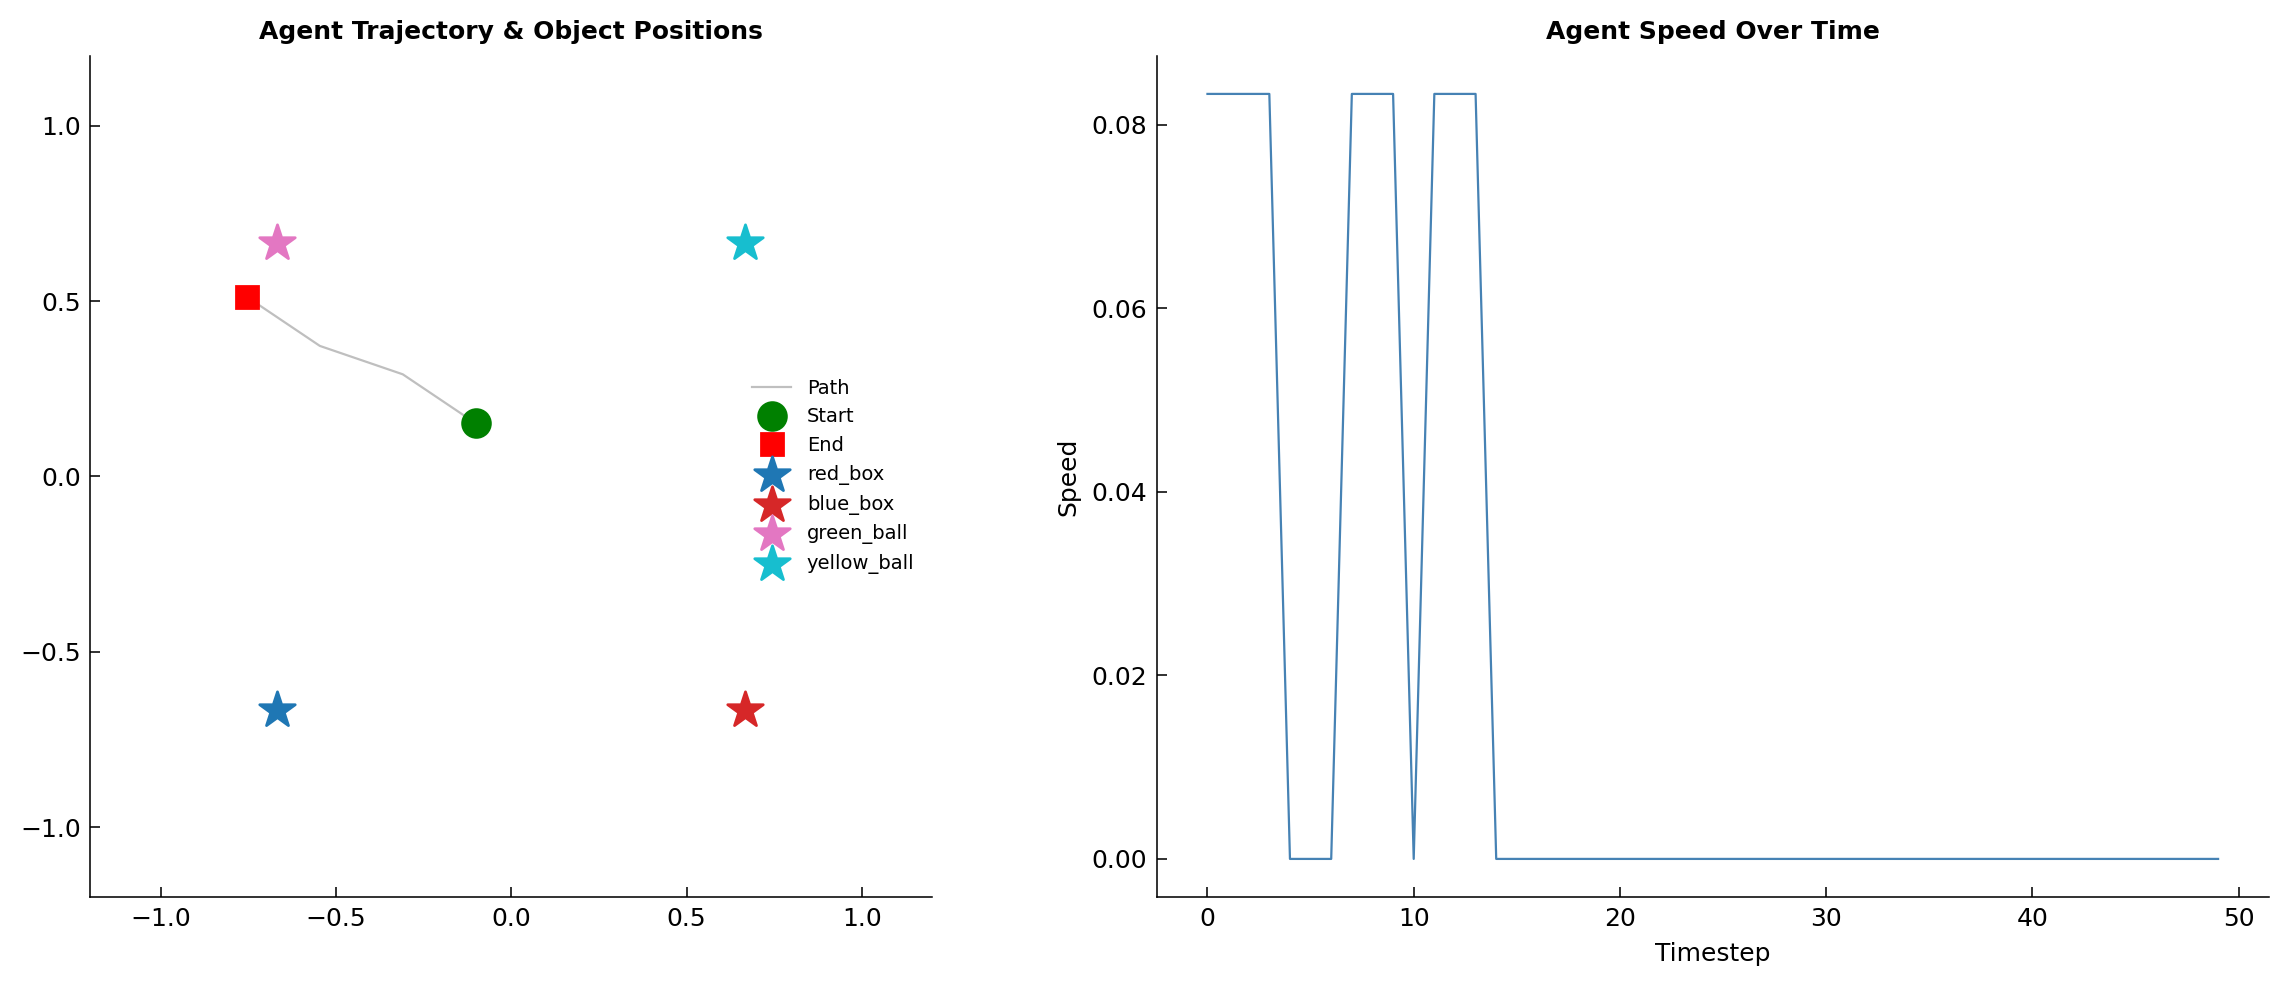

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Trajectory map
axes[0].plot(path[:, 0], path[:, 1], color='gray', alpha=0.5, lw=0.8, label='Path')
axes[0].plot(*path[0],  'go', ms=10, label='Start')
axes[0].plot(*path[-1], 'rs', ms=8,  label='End')
colors = plt.cm.tab10(np.linspace(0, 1, n_obj))
for i, (pos, name) in enumerate(zip(landmark_positions, labels)):
    axes[0].scatter(*pos, s=180, marker='*', color=colors[i], zorder=5, label=name)
axes[0].set_xlim(-1.2, 1.2); axes[0].set_ylim(-1.2, 1.2)
axes[0].set_aspect('equal')
axes[0].legend(fontsize=7)
axes[0].set_title('Agent Trajectory & Object Positions')

# Speed profile
speed = np.linalg.norm(velocities, axis=1)
axes[1].plot(speed, color='steelblue', lw=0.8)
axes[1].set_title('Agent Speed Over Time')
axes[1].set_xlabel('Timestep'); axes[1].set_ylabel('Speed')

plt.tight_layout()
plt.show()

## 6. Encode Features as SPs — Verify Object Distinctiveness

Before running SLAM, we can check whether the feature vectors for different objects
map to sufficiently distinct SPs.

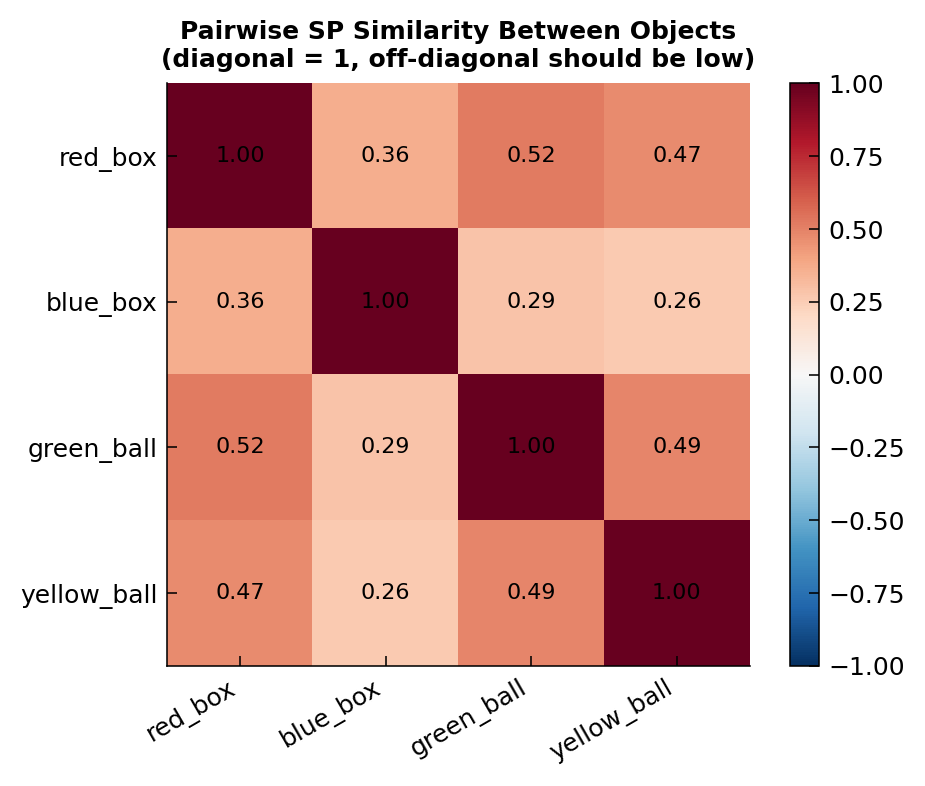

Off-diagonal similarities (lower is better for discrimination):
  Mean: 0.397  |  Max: 0.518


In [98]:
ssp_dim = 97   # matches the saved SLAM run (sspdim_97)
img_encoder = ImageFeatureEncoder(feat_dim=feat_dim, ssp_dim=ssp_dim, seed=0)

# Encode mean appearance per object (average features over all timesteps)
mean_feats = feature_vectors.mean(axis=0)   # (n_obj, feat_dim)
obj_sps    = img_encoder.encode(mean_feats) # (n_obj, ssp_dim)

# Pairwise similarity matrix
sim_matrix = obj_sps @ obj_sps.T

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(sim_matrix, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(n_obj)); ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_yticks(range(n_obj)); ax.set_yticklabels(labels)
plt.colorbar(im, ax=ax)
ax.set_title('Pairwise SP Similarity Between Objects\n(diagonal = 1, off-diagonal should be low)')

for i in range(n_obj):
    for j in range(n_obj):
        ax.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("Off-diagonal similarities (lower is better for discrimination):")
off_diag = sim_matrix[~np.eye(n_obj, dtype=bool)]
print(f"  Mean: {off_diag.mean():.3f}  |  Max: {off_diag.max():.3f}")

## 7. Visualise SLAM Results

Load the saved SLAM simulation output and plot estimated vs true positions.

Loading: slam_features_sspdim_97_featdim_128_pinneurons_300_T_30_seed_0.npz


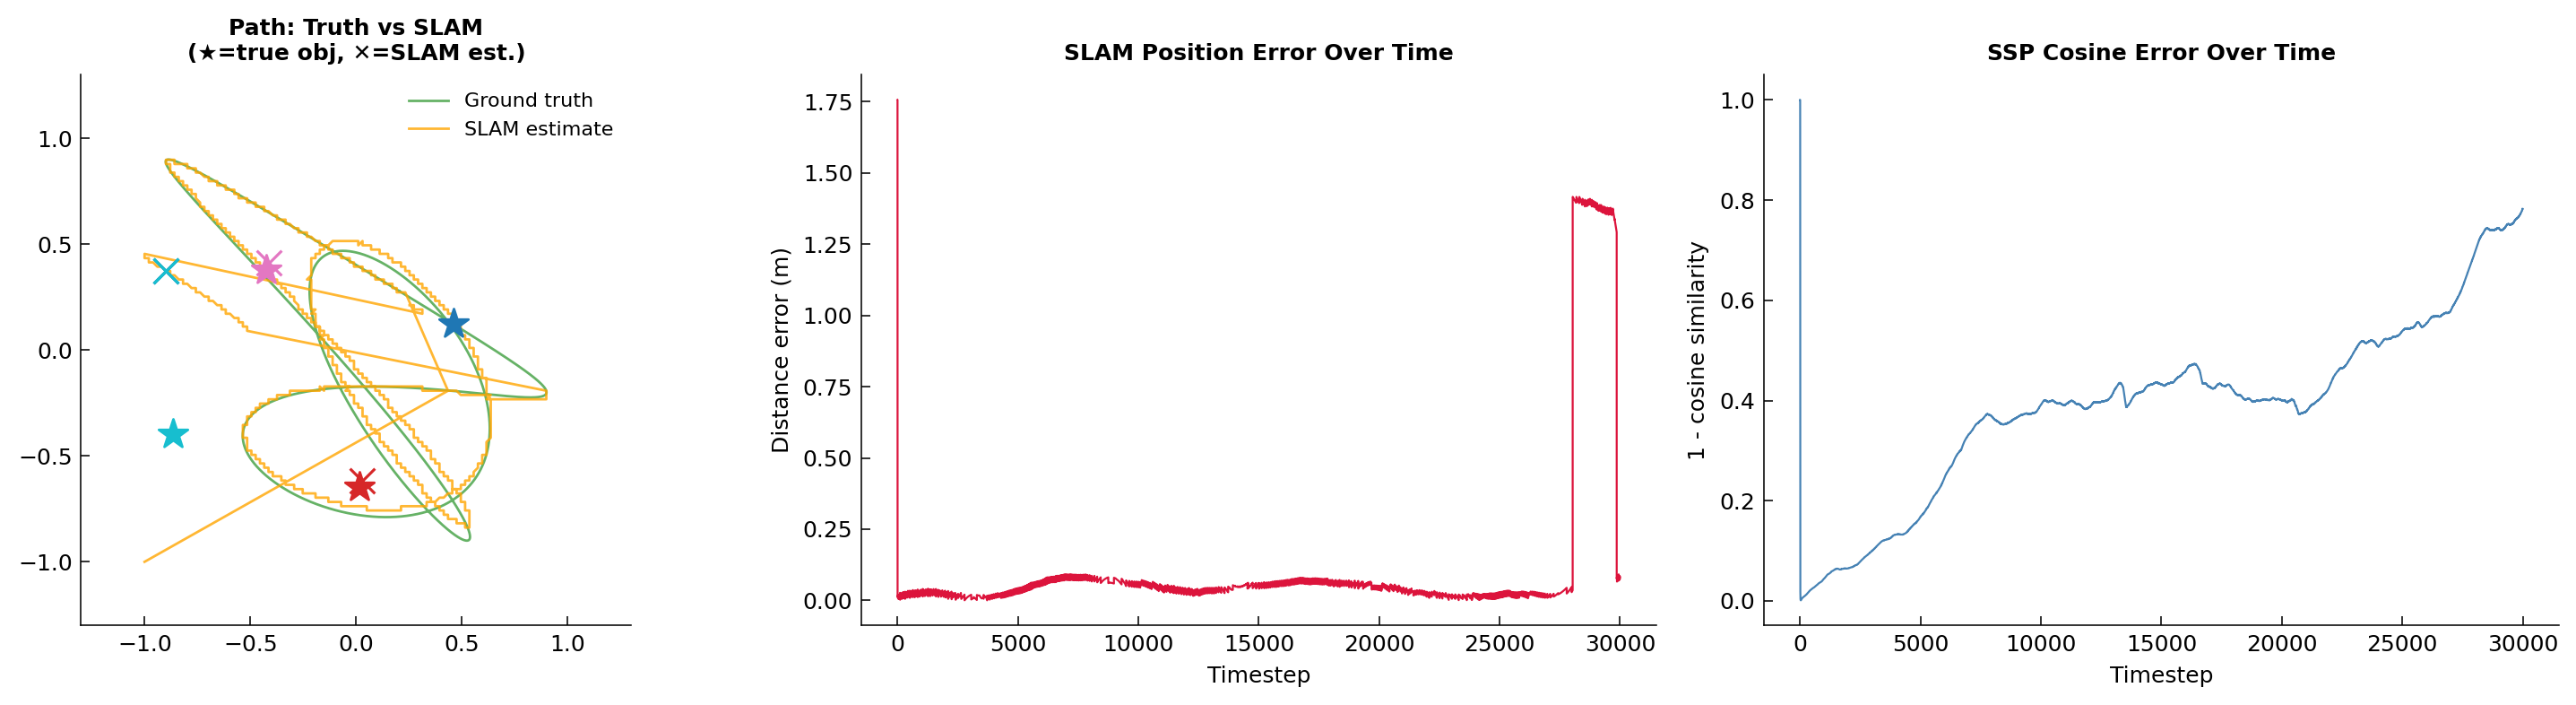

Mean cosine similarity: 0.610
Mean position error:    0.1223 m
Final position error:   0.0811 m


In [99]:
import glob

npz_files = sorted(glob.glob(os.path.join(DATA_DIR, 'slam_features_*.npz')))
if not npz_files:
    print("No SLAM results found. Run:")
    print("  python experiments/run_slam_features.py --T 30 --n-landmarks 4 --save --save-dir data/3d")
else:
    # Prefer the longest simulation (largest T value in filename)
    def get_T(f): 
        import re; m = re.search(r'_T_(\d+)_', f); return int(m.group(1)) if m else 0
    npz_path = max(npz_files, key=get_T)
    print(f"Loading: {os.path.basename(npz_path)}")
    res = np.load(npz_path, allow_pickle=True)

    slam_path     = res['slam_path']
    true_path     = res['path']
    slam_error    = res['slam_error']
    slam_sims     = res['slam_sims']
    obj_locs      = res['obj_locs']
    landmark_locs = res['landmark_loc_est']

    colors = plt.cm.tab10(np.linspace(0, 1, len(obj_locs)))
    obj_labels = [f'obj_{i}' for i in range(len(obj_locs))]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(*true_path.T,  label='Ground truth', color='green',  alpha=0.6, lw=1)
    axes[0].plot(*slam_path.T,  label='SLAM estimate', color='orange', alpha=0.8, lw=1)
    for i, (true_p, est_p) in enumerate(zip(obj_locs, landmark_locs)):
        axes[0].scatter(*true_p, marker='*', s=150, color=colors[i], zorder=5)
        axes[0].scatter(*est_p,  marker='x', s=100, color=colors[i], zorder=5)
    axes[0].set_xlim(-1.3, 1.3); axes[0].set_ylim(-1.3, 1.3)
    axes[0].set_aspect('equal')
    axes[0].legend(fontsize=8)
    axes[0].set_title('Path: Truth vs SLAM\n(★=true obj, ✕=SLAM est.)')

    axes[1].plot(slam_error, color='crimson', lw=0.8)
    axes[1].set_xlabel('Timestep'); axes[1].set_ylabel('Distance error (m)')
    axes[1].set_title('SLAM Position Error Over Time')

    axes[2].plot(1 - slam_sims, color='steelblue', lw=0.8)
    axes[2].set_xlabel('Timestep'); axes[2].set_ylabel('1 - cosine similarity')
    axes[2].set_title('SSP Cosine Error Over Time')

    plt.tight_layout()
    plt.show()

    print(f"Mean cosine similarity: {slam_sims.mean():.3f}")
    print(f"Mean position error:    {slam_error.mean():.4f} m")
    print(f"Final position error:   {slam_error[-1]:.4f} m")

## 8. Spatial Query — Where Does the Map Think Each Object Is?

Using the learned landmark SSPs, we plot spatial similarity heatmaps
to visualise where the SLAM network has encoded each object.

In [ ]:
if 'res' not in dir():
    print("Run the cell above first to load SLAM results.")
else:
    landmark_ssps = res['landmark_ssps_est']   # (n_obj, ssp_dim)
    ssp_dim_saved = landmark_ssps.shape[1]
    n_obj_saved   = landmark_ssps.shape[0]

    ssp_space_q = HexagonalSSPSpace(
        domain_dim=2, ssp_dim=ssp_dim_saved,
        domain_bounds=np.array([[-1, 1], [-1, 1]])
    )

    # Build query grid
    res_q = 60
    xs_q = np.linspace(-1, 1, res_q)
    ys_q = np.linspace(-1, 1, res_q)
    xx_q, yy_q = np.meshgrid(xs_q, ys_q)
    grid_pts_q  = np.stack([xx_q.ravel(), yy_q.ravel()], axis=1)
    grid_ssps_q = ssp_space_q.encode(grid_pts_q)   # (res^2, ssp_dim)

    colors_q = plt.cm.tab10(np.linspace(0, 1, n_obj_saved))

    fig, axes = plt.subplots(1, n_obj_saved, figsize=(4 * n_obj_saved, 4))
    if n_obj_saved == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        sims = (grid_ssps_q @ landmark_ssps[i]).reshape(res_q, res_q)
        im = ax.imshow(sims, origin='lower', extent=[-1, 1, -1, 1],
                       cmap='hot', interpolation='bilinear')
        ax.scatter(*obj_locs[i],      s=140, marker='*', color='cyan', zorder=5, label='True')
        ax.scatter(*landmark_locs[i], s=90,  marker='x', color='lime', zorder=5, label='SLAM est.')
        ax.set_title(f'Object {i}')
        ax.set_xlabel('x'); ax.set_ylabel('y')
        ax.legend(fontsize=7)
        plt.colorbar(im, ax=ax, shrink=0.8)

    plt.suptitle('Learned Location SSPs — Spatial Similarity Heatmaps\n'
                 '(bright peak = where SLAM thinks each object is)', fontsize=12)
    plt.tight_layout()
    plt.show()

---

## Next Steps

- **Run the full SLAM pipeline**: `python experiments/run_slam_features.py`
- **Semantic queries with CLIP**: open `slam_3d_dashboard.ipynb` → Section 3d
- **3D collection + SLAM**: `python experiments/run_slam_3d.py --policy explore`
- **Semantic class encoding**: `python experiments/run_semantic_slam.py --backend cpu`
- **Read the theory**: `README.md` covers SSP math, grid cells, and path integration